In [2]:
from src.MPOptoClass import *
from src.utils.gen_utils import *
from src.utils.filters import *
from src.helpers.experiment import *
from src.wiener_filter import *
from src.modeller import *
from src.MPRecordClass import *
from src.ReachingClass import *
import scipy
import copy
import time
import mat73 
import pynapple as nap
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
import random
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from itertools import permutations, compress, product




%load_ext autoreload 
%autoreload 2
%matplotlib widget

In [4]:
session_path = '../data/co/co9/co9_12122023'
session = MPOptoClass(session_path)
output = pload('/home/diya/Documents/mp_opto/picklejar/sweepRegsSW_9log_co9.pickle')

love


# revisiting range of models

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


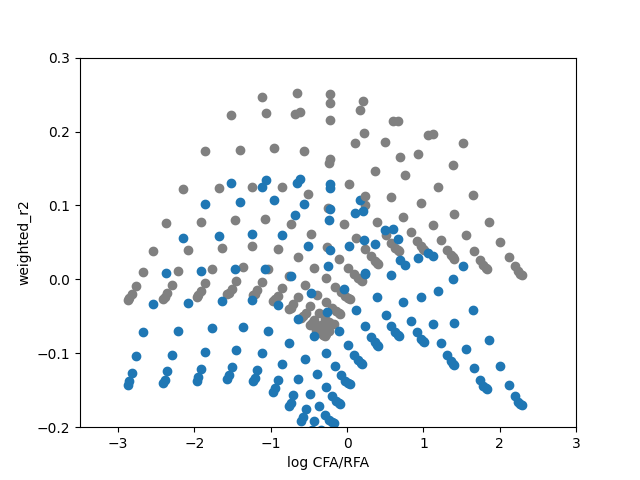

In [45]:
fig, ax = plt.subplots()
ratio_list = []
ratio2_list = []
h_list = []
laser_score_list = []
ctrl_score_list = []

raw_weights_list = []

tlaser_score_list =[]
tctrl_score_list = []
for idx, o in enumerate(output):
    h = o[0]
    h_stim = o[3]
    laser_score = o[1]
    ctrl_score = o[2]
    
    tlaser_score = o[4]
    tctrl_score = o[5]
    
    temp = session.weights_per_region(h)
    ratio = np.log10(temp[0]/temp[1])
    
    if min(temp) < .01:
        continue
    
    
    
    raw_weights_list.append(temp)
    
    temp2 = session.weights_per_region(h_stim)
    
    if min(temp2) < .01:
        continue
    ratio2 = np.log10(temp2[0]/temp2[1])
    
    
    ratio_list.append(ratio)
    ratio2_list.append(ratio2)
    h_list.append(h)
    laser_score_list.append(laser_score)
    ctrl_score_list.append(ctrl_score)
    tlaser_score_list.append(tlaser_score)
    tctrl_score_list.append(tctrl_score)
    
    #ax.scatter(ratio, o[1], color='blue')
    #ax.scatter(ratio, o[2], color='black')
    ax.scatter(ratio2, o[4], color='tab:blue')
    ax.scatter(ratio2, o[5], color='gray')
    ax.set_ylim(-0.2,0.3)
    ax.set_xlim(-3.5,3)
    ax.set_ylabel('weighted_r2')
    ax.set_xlabel('log CFA/RFA')
#ax.legend()

In [40]:
reg_terms = np.logspace(0,9,20)
reg_combos = list(product(reg_terms, reg_terms))
laser_score_list = np.array(laser_score_list)
ctrl_score_list = np.array(ctrl_score_list)
tlaser_score_list = np.array(tlaser_score_list)
tctrl_score_list = np.array(tctrl_score_list)
raw_weights_list = np.squeeze(np.array(raw_weights_list))
ratio_list = np.array(ratio_list)
ratio2_list = np.array(ratio2_list)
nada, bin_ratio_edges = np.histogram(ratio_list, bins=15)

laser_score_keep = []
ctrl_score_keep = []
tlaser_score_keep = []
tctrl_score_keep = []
ratio_keep = []
ratio2_keep = []
raw_weights = []

for i in range(bin_ratio_edges.size - 1):
    condition1 = ratio_list > bin_ratio_edges[i]
    condition2 = ratio_list < bin_ratio_edges[i+1]
    indices = np.argwhere(np.logical_and(condition1,condition2))
    
    keep = np.argmax(tctrl_score_list[indices]) 
    temp1 = tctrl_score_list[indices]
    temp2 = temp1[keep]
    tctrl_score_keep.append(temp2)
    
    temp1 = ratio2_list[indices]
    temp2 = temp1[keep]
    ratio2_keep.append(temp2)
    
    keep = np.argmax(ctrl_score_list[indices])
    temp1 = ctrl_score_list[indices]
    temp2 = temp1[keep]
    ctrl_score_keep.append(temp2) 
    
    temp1 = ratio_list[indices]
    temp2 = temp1[keep]
    ratio_keep.append(temp2)
    
        

    
    #indices = np.argwhere(np.logical_and(condition1,condition2))
    #keep = np.argmax(ctrl_score_list[indices])
    


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


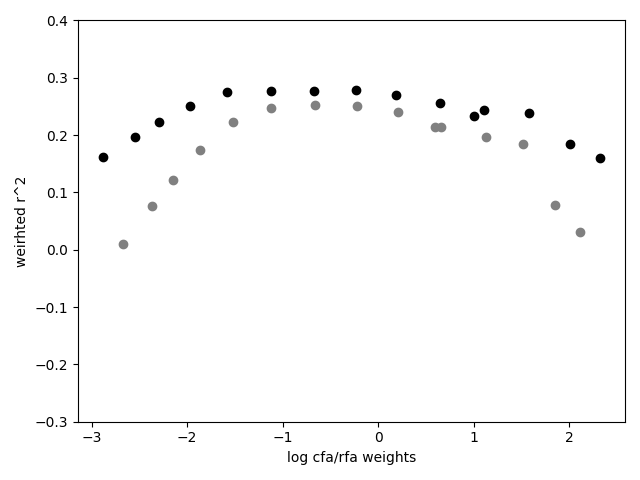

In [42]:
fig2, ax2 = plt.subplots()
ax2.scatter(ratio2_keep, tctrl_score_keep, c='gray', label='stim')
ax2.scatter(ratio_keep, ctrl_score_keep, c='black', label='ctrl')
#ax2[1].scatter(ratio2_keep, tlaser_score_keep, c='tab:blue', label='stim')
#ax2[1].scatter(ratio2_keep, tctrl_score_keep, c='black', label='ctrl')
#ax2[1].scatter(ratio_keep, laser_score_keep, c='tab:blue', label='activity model stim', alpha=0.2)
#ax2[1].scatter(ratio_keep, ctrl_score_keep, c='black', label='activity model ctrl', alpha=0.2)
ax2.set_ylabel('weirhted r^2')
#ax2[1].set_ylabel('weirhted r^2')
ax2.set_xlabel('log cfa/rfa weights')
#ax2.axhline(best_CFA_score, c='tab:blue', linestyle='--', label='CFA only r2 score')
#ax2.axhline(best_RFA_score, c= 'tab:red', linestyle='--', label='RFA only r2 score')
#ax2.legend()
#ax2[1].legend()
#ax2.set_title('co9 activity model \n (predicting RFA PCs, stim CFA, 10 ms bins, 10 lags)')
#ax2[1].set_title('co9, activity + stims model')


ax2.set_ylim(-.3, .4)
fig2.tight_layout()

# co6, predicting all CFA/RFA from all CFA/RFA climbing, first 20 PCs

In [ ]:
binsizes = [10,20,50]
num_PCs=20
nlags=10

r2_list = []
r2_cfa_list=[]

for binsize in binsizes:
    (X, Y), PCA_Objs = session.format_nlags_PCA(bounds = session.climbing_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs)
    y,yhat, _ = wiener_kfolds(X, Y, c=(2,6))
    r2_list.append(weighted_r2(y,yhat, remove_lows=False))
    r2_cfa_list.append(weighted_r2(y[:,:num_PCs],yhat[:,:num_PCs]))
    
#50 ms bins, but with one history modele
nlags=1
r2_1lag_list = []

for binsize in binsizes:
    (X, Y), PCA_Objs = session.format_nlags_PCA(bounds = session.climbing_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs)
    y,yhat, _ = wiener_kfolds(X, Y, c=(2,6))
    r2_1lag_list.append(weighted_r2(y,yhat))
    

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


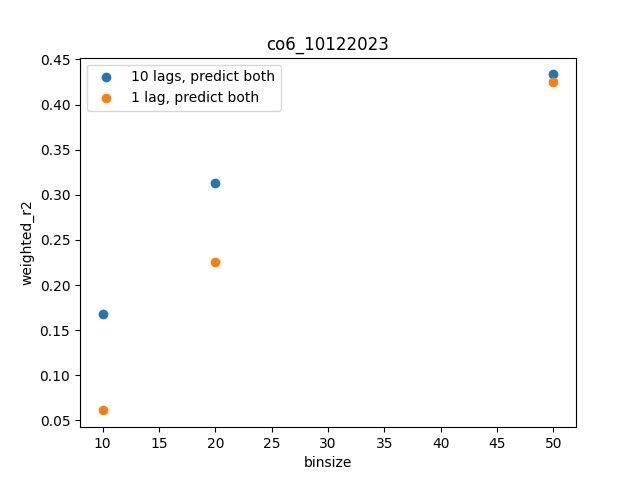

In [40]:
fig0, ax0 = plt.subplots()
ax0.set_xlabel('binsize')
ax0.set_ylabel('weighted_r2')
ax0.scatter(binsizes, r2_list, label='10 lags, predict both')
ax0.scatter(binsizes, r2_1lag_list, label='1 lag, predict both')
ax0.set_title('co6_10122023')
ax0.legend()